In [30]:
import nflreadpy as nfl
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

In [6]:
schedules = nfl.load_schedules(
    seasons=range(2015, 2026)
)

schedules.head()


game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,old_game_id,gsis,nfl_detail_id,pfr,pff,espn,ftn,away_rest,home_rest,away_moneyline,home_moneyline,spread_line,away_spread_odds,home_spread_odds,total_line,under_odds,over_odds,div_game,roof,surface,temp,wind,away_qb_id,home_qb_id,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium_id,stadium
str,i32,str,i32,str,str,str,str,i32,str,i32,str,i32,i32,i32,str,i32,str,str,i32,str,i32,i32,i32,i32,i32,f64,i32,i32,f64,i32,i32,i32,str,str,i32,i32,str,str,str,str,str,str,str,str,str
"""2015_01_PIT_NE""",2015,"""REG""",1,"""2015-09-10""","""Thursday""","""20:30""","""PIT""",21,"""NE""",28,"""Home""",7,49,0,"""2015091000""",56503,null,"""201509100nwe""",3406,"""400791485""",null,7,7,305,-350,7.5,-111,101,51.0,-107,-103,0,"""outdoors""","""fieldturf""",65,7,"""00-0022924""","""00-0019596""","""Ben Roethlisberger""","""Tom Brady""","""Mike Tomlin""","""Bill Belichick""","""Carl Cheffers""","""BOS00""","""Gillette Stadium"""
"""2015_01_IND_BUF""",2015,"""REG""",1,"""2015-09-13""","""Sunday""","""13:00""","""IND""",14,"""BUF""",27,"""Home""",13,41,0,"""2015091304""",56504,null,"""201509130buf""",3413,"""400791541""",null,7,7,-109,-101,-1.0,-103,-107,44.5,102,-113,0,"""outdoors""","""a_turf""",56,15,"""00-0029668""","""00-0028118""","""Andrew Luck""","""Tyrod Taylor""","""Chuck Pagano""","""Rex Ryan""","""John Parry""","""BUF00""","""Ralph Wilson Stadium"""
"""2015_01_GB_CHI""",2015,"""REG""",1,"""2015-09-13""","""Sunday""","""13:00""","""GB""",31,"""CHI""",23,"""Home""",-8,54,0,"""2015091300""",56505,null,"""201509130chi""",3407,"""400791489""",null,7,7,-250,222,-5.5,-110,100,48.5,-107,-103,1,"""outdoors""","""grass""",72,11,"""00-0023459""","""00-0024226""","""Aaron Rodgers""","""Jay Cutler""","""Mike McCarthy""","""John Fox""","""Craig Wrolstad""","""CHI98""","""Soldier Field"""
"""2015_01_KC_HOU""",2015,"""REG""",1,"""2015-09-13""","""Sunday""","""13:00""","""KC""",27,"""HOU""",20,"""Home""",-7,47,0,"""2015091306""",56506,null,"""201509130htx""",3409,"""400791493""",null,7,7,-105,-105,-1.0,100,-110,41.0,-103,-107,0,"""closed""","""grass""",null,null,"""00-0023436""","""00-0026625""","""Alex Smith""","""Brian Hoyer""","""Andy Reid""","""Bill O'Brien""","""Peter Morelli""","""HOU00""","""NRG Stadium"""
"""2015_01_CAR_JAX""",2015,"""REG""",1,"""2015-09-13""","""Sunday""","""13:00""","""CAR""",20,"""JAX""",9,"""Home""",-11,29,0,"""2015091302""",56507,null,"""201509130jax""",3411,"""400791547""",null,7,7,-145,131,-3.0,-100,-110,41.0,-107,-103,0,"""outdoors""","""grass""",77,7,"""00-0027939""","""00-0031407""","""Cam Newton""","""Blake Bortles""","""Ron Rivera""","""Gus Bradley""","""Ron Torbert""","""JAX00""","""EverBank Field"""


In [13]:
games = games.with_columns(
    (
        pl.col("home_score") > pl.col("away_score")
    )
    .cast(pl.Int8)
    .alias("home_win")
)

In [14]:
games.head()

game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,old_game_id,gsis,nfl_detail_id,pfr,pff,espn,ftn,away_rest,home_rest,away_moneyline,home_moneyline,spread_line,away_spread_odds,home_spread_odds,total_line,under_odds,over_odds,div_game,roof,surface,temp,wind,away_qb_id,home_qb_id,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium_id,stadium,home_win
str,i32,str,i32,str,str,str,str,i32,str,i32,str,i32,i32,i32,str,i32,str,str,i32,str,i32,i32,i32,i32,i32,f64,i32,i32,f64,i32,i32,i32,str,str,i32,i32,str,str,str,str,str,str,str,str,str,i8
"""2015_01_PIT_NE""",2015,"""REG""",1,"""2015-09-10""","""Thursday""","""20:30""","""PIT""",21,"""NE""",28,"""Home""",7,49,0,"""2015091000""",56503,null,"""201509100nwe""",3406,"""400791485""",null,7,7,305,-350,7.5,-111,101,51.0,-107,-103,0,"""outdoors""","""fieldturf""",65,7,"""00-0022924""","""00-0019596""","""Ben Roethlisberger""","""Tom Brady""","""Mike Tomlin""","""Bill Belichick""","""Carl Cheffers""","""BOS00""","""Gillette Stadium""",1
"""2015_01_IND_BUF""",2015,"""REG""",1,"""2015-09-13""","""Sunday""","""13:00""","""IND""",14,"""BUF""",27,"""Home""",13,41,0,"""2015091304""",56504,null,"""201509130buf""",3413,"""400791541""",null,7,7,-109,-101,-1.0,-103,-107,44.5,102,-113,0,"""outdoors""","""a_turf""",56,15,"""00-0029668""","""00-0028118""","""Andrew Luck""","""Tyrod Taylor""","""Chuck Pagano""","""Rex Ryan""","""John Parry""","""BUF00""","""Ralph Wilson Stadium""",1
"""2015_01_GB_CHI""",2015,"""REG""",1,"""2015-09-13""","""Sunday""","""13:00""","""GB""",31,"""CHI""",23,"""Home""",-8,54,0,"""2015091300""",56505,null,"""201509130chi""",3407,"""400791489""",null,7,7,-250,222,-5.5,-110,100,48.5,-107,-103,1,"""outdoors""","""grass""",72,11,"""00-0023459""","""00-0024226""","""Aaron Rodgers""","""Jay Cutler""","""Mike McCarthy""","""John Fox""","""Craig Wrolstad""","""CHI98""","""Soldier Field""",0
"""2015_01_KC_HOU""",2015,"""REG""",1,"""2015-09-13""","""Sunday""","""13:00""","""KC""",27,"""HOU""",20,"""Home""",-7,47,0,"""2015091306""",56506,null,"""201509130htx""",3409,"""400791493""",null,7,7,-105,-105,-1.0,100,-110,41.0,-103,-107,0,"""closed""","""grass""",null,null,"""00-0023436""","""00-0026625""","""Alex Smith""","""Brian Hoyer""","""Andy Reid""","""Bill O'Brien""","""Peter Morelli""","""HOU00""","""NRG Stadium""",0
"""2015_01_CAR_JAX""",2015,"""REG""",1,"""2015-09-13""","""Sunday""","""13:00""","""CAR""",20,"""JAX""",9,"""Home""",-11,29,0,"""2015091302""",56507,null,"""201509130jax""",3411,"""400791547""",null,7,7,-145,131,-3.0,-100,-110,41.0,-107,-103,0,"""outdoors""","""grass""",77,7,"""00-0027939""","""00-0031407""","""Cam Newton""","""Blake Bortles""","""Ron Rivera""","""Gus Bradley""","""Ron Torbert""","""JAX00""","""EverBank Field""",0


In [15]:
games.shape

(2895, 47)

In [16]:
games.columns

['game_id',
 'season',
 'game_type',
 'week',
 'gameday',
 'weekday',
 'gametime',
 'away_team',
 'away_score',
 'home_team',
 'home_score',
 'location',
 'result',
 'total',
 'overtime',
 'old_game_id',
 'gsis',
 'nfl_detail_id',
 'pfr',
 'pff',
 'espn',
 'ftn',
 'away_rest',
 'home_rest',
 'away_moneyline',
 'home_moneyline',
 'spread_line',
 'away_spread_odds',
 'home_spread_odds',
 'total_line',
 'under_odds',
 'over_odds',
 'div_game',
 'roof',
 'surface',
 'temp',
 'wind',
 'away_qb_id',
 'home_qb_id',
 'away_qb_name',
 'home_qb_name',
 'away_coach',
 'home_coach',
 'referee',
 'stadium_id',
 'stadium',
 'home_win']

In [18]:
games.schema

Schema([('game_id', String),
        ('season', Int32),
        ('game_type', String),
        ('week', Int32),
        ('gameday', String),
        ('weekday', String),
        ('gametime', String),
        ('away_team', String),
        ('away_score', Int32),
        ('home_team', String),
        ('home_score', Int32),
        ('location', String),
        ('result', Int32),
        ('total', Int32),
        ('overtime', Int32),
        ('old_game_id', String),
        ('gsis', Int32),
        ('nfl_detail_id', String),
        ('pfr', String),
        ('pff', Int32),
        ('espn', String),
        ('ftn', Int32),
        ('away_rest', Int32),
        ('home_rest', Int32),
        ('away_moneyline', Int32),
        ('home_moneyline', Int32),
        ('spread_line', Float64),
        ('away_spread_odds', Int32),
        ('home_spread_odds', Int32),
        ('total_line', Float64),
        ('under_odds', Int32),
        ('over_odds', Int32),
        ('div_game', Int32),
        ('r

In [19]:
games.glimpse()

Rows: 2895
Columns: 47
$ game_id          <str> '2015_01_PIT_NE', '2015_01_IND_BUF', '2015_01_GB_CHI', '2015_01_KC_HOU', '2015_01_CAR_JAX', '2015_01_CLE_NYJ', '2015_01_SEA_STL', '2015_01_MIA_WAS', '2015_01_NO_ARI', '2015_01_DET_SD'
$ season           <i32> 2015, 2015, 2015, 2015, 2015, 2015, 2015, 2015, 2015, 2015
$ game_type        <str> 'REG', 'REG', 'REG', 'REG', 'REG', 'REG', 'REG', 'REG', 'REG', 'REG'
$ week             <i32> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1
$ gameday          <str> '2015-09-10', '2015-09-13', '2015-09-13', '2015-09-13', '2015-09-13', '2015-09-13', '2015-09-13', '2015-09-13', '2015-09-13', '2015-09-13'
$ weekday          <str> 'Thursday', 'Sunday', 'Sunday', 'Sunday', 'Sunday', 'Sunday', 'Sunday', 'Sunday', 'Sunday', 'Sunday'
$ gametime         <str> '20:30', '13:00', '13:00', '13:00', '13:00', '13:00', '13:00', '13:00', '16:05', '16:05'
$ away_team        <str> 'PIT', 'IND', 'GB', 'KC', 'CAR', 'CLE', 'SEA', 'MIA', 'NO', 'DET'
$ away_score       <i32> 21, 14, 31, 27, 

In [17]:
games.select([
    "season",
    "week",
    "home_team",
    "away_team",
    "home_score",
    "away_score",
    "home_win"
]).head(10)

season,week,home_team,away_team,home_score,away_score,home_win
i32,i32,str,str,i32,i32,i8
2015,1,"""NE""","""PIT""",28,21,1
2015,1,"""BUF""","""IND""",27,14,1
2015,1,"""CHI""","""GB""",23,31,0
2015,1,"""HOU""","""KC""",20,27,0
2015,1,"""JAX""","""CAR""",9,20,0
2015,1,"""NYJ""","""CLE""",31,10,1
2015,1,"""STL""","""SEA""",34,31,1
2015,1,"""WAS""","""MIA""",10,17,0
2015,1,"""ARI""","""NO""",31,19,1


In [20]:
games.describe()

statistic,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,old_game_id,gsis,nfl_detail_id,pfr,pff,espn,ftn,away_rest,home_rest,away_moneyline,home_moneyline,spread_line,away_spread_odds,home_spread_odds,total_line,under_odds,over_odds,div_game,roof,surface,temp,wind,away_qb_id,home_qb_id,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium_id,stadium,home_win
str,str,f64,str,f64,str,str,str,str,f64,str,f64,str,f64,f64,f64,str,f64,str,str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,str,str,str,str,str,str,str,str,str,f64
"""count""","""2895""",2895.0,"""2895""",2895.0,"""2895""","""2895""","""2895""","""2895""",2895.0,"""2895""",2895.0,"""2895""",2895.0,2895.0,2895.0,"""2895""",2895.0,"""272""","""2895""",2080.0,"""2895""",1598.0,2895.0,2895.0,2894.0,2894.0,2895.0,2894.0,2894.0,2895.0,2894.0,2894.0,2895.0,"""2895""","""2895""",1900.0,1900.0,"""2895""","""2895""","""2895""","""2895""","""2895""","""2895""","""2894""","""2895""","""2895""",2895.0
"""null_count""","""0""",0.0,"""0""",0.0,"""0""","""0""","""0""","""0""",0.0,"""0""",0.0,"""0""",0.0,0.0,0.0,"""0""",0.0,"""2623""","""0""",815.0,"""0""",1297.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,"""0""","""0""",995.0,995.0,"""0""","""0""","""0""","""0""","""0""","""0""","""1""","""0""","""0""",0.0
"""mean""",null,2020.082211,null,9.256304,null,null,null,null,21.922971,null,23.663212,null,1.740242,45.586183,0.056995,null,58352.398964,null,null,13431.946154,null,5986.158323,7.464594,7.393437,57.452315,-112.779544,1.760794,-72.376987,-70.328265,45.18601,-84.486524,-86.344851,0.364767,null,null,58.624737,8.240526,null,null,null,null,null,null,null,null,null,0.544041
"""std""",null,3.166451,null,5.149386,null,null,null,null,9.796192,null,10.036158,null,14.200785,13.846206,0.231873,null,1045.348342,null,null,8157.191163,null,599.303377,2.048827,2.017792,281.357996,315.130553,6.035575,80.272095,82.152552,4.322063,66.009073,63.987495,0.481448,null,null,17.147126,5.141755,null,null,null,null,null,null,null,null,null,0.498143
"""min""","""2015_01_BAL_DEN""",2015.0,"""REG""",1.0,"""2015-09-10""","""Friday""","""09:30""","""ARI""",0.0,"""ARI""",0.0,"""Home""",-49.0,3.0,0.0,"""2015091000""",56503.0,"""10160000-0585-0395-7f87-0c3334…","""201509100nwe""",3406.0,"""400761514""",5058.0,4.0,4.0,-1800.0,-2540.0,-18.0,-134.0,-133.0,28.5,-125.0,-125.0,0.0,"""closed""","""""",1.0,0.0,"""00-0007091""","""00-0007091""","""A.J. McCarron""","""A.J. McCarron""","""Aaron Glenn""","""Aaron Glenn""","""Adrian Hall""","""ATL00""","""AT&T Stadium""",0.0
"""25%""",null,2017.0,null,5.0,null,null,null,null,16.0,null,17.0,null,-7.0,36.0,0.0,null,57446.0,null,null,7930.0,null,5469.0,7.0,7.0,-155.0,-254.0,-3.0,-111.0,-111.0,42.0,-110.0,-110.0,0.0,null,null,46.0,5.0,null,null,null,null,null,null,null,null,null,0.0
"""50%""",null,2020.0,null,9.0,null,null,null,null,21.0,null,24.0,null,2.0,45.0,0.0,null,58335.0,null,null,13778.0,null,5895.0,7.0,7.0,129.0,-145.0,2.5,-107.0,-107.0,45.0,-107.0,-108.0,0.0,null,null,59.0,7.0,null,null,null,null,null,null,null,null,null,1.0
"""75%""",null,2023.0,null,14.0,null,null,null,null,28.0,null,30.0,null,10.0,54.0,0.0,null,59265.0,null,null,19631.0,null,6593.0,7.0,7.0,220.0,136.0,6.0,-102.0,-102.0,48.0,-103.0,-103.0,1.0,null,null,72.0,11.0,null,null,null,null,null,null,null,null,null,1.0
"""max""","""2025_18_WAS_PHI""",2025.0,"""REG""",18.0,"""2026-01-04""","""Wednesday""","""22:20""","""WAS""",59.0,"""WAS""",70.0,"""Neutral""",50.0,105.0,1.0,"""2026010413""",60114.0,"""10160000-0587-7450-0923-b0f39c…","""202601040ram""",28689.0,"""401772970""",7005.0,17.0,16.0,1454.0,1000.0,22.0,120.0,121.0,63.5,113.0,113.0,1.0,"""outdoors""","""sportturf""",97.0,71.0,"""00-0040743""","""00-0040743""","""Zach Wilson""","""Zach Wilson""","""Zac Taylor""","""Zac Taylor""","""Walt Coleman""","""WAS00""","""Wembley Stadium""",1.0


In [21]:
schedules.group_by("game_type").agg(
    pl.len().alias("games")
).sort("games", descending=True)

game_type,games
str,u32
"""REG""",2895
"""WC""",56
"""DIV""",44
"""CON""",22
"""SB""",11


In [22]:
games.group_by("season").agg(
    pl.len().alias("games")
).sort("season")

season,games
i32,u32
2015,256
2016,256
2017,256
2018,256
2019,256
…,…
2021,272
2022,271
2023,272


In [23]:
games.select([
    pl.col("home_score").mean().alias("home_mean"),
    pl.col("away_score").mean().alias("away_mean"),
    pl.col("home_score").median().alias("home_median"),
    pl.col("away_score").median().alias("away_median"),
])

home_mean,away_mean,home_median,away_median
f64,f64,f64,f64
23.663212,21.922971,24.0,21.0


In [24]:
games = games.with_columns(
    (
        pl.col("home_score") - pl.col("away_score")
    ).alias("score_diff")
)

In [25]:
games.select([
    pl.col("score_diff").mean().alias("mean_margin"),
    pl.col("score_diff").median().alias("median_margin"),
    pl.col("score_diff").std().alias("std_margin"),
    pl.col("score_diff").min().alias("min_margin"),
    pl.col("score_diff").max().alias("max_margin"),
])

mean_margin,median_margin,std_margin,min_margin,max_margin
f64,f64,f64,i32,i32
1.740242,2.0,14.200785,-49,50


In [26]:
games.group_by("home_win").agg(
    pl.len().alias("games")
)

home_win,games
i8,u32
1,1575
0,1320


In [27]:
games.select(
    pl.col("home_win").mean().alias("home_win_rate")
)

home_win_rate
f64
0.544041


In [28]:
home_win_by_year = (
    games
    .group_by("season")
    .agg(
        pl.col("home_win").mean().alias("home_win_rate")
    )
    .sort("season")
)

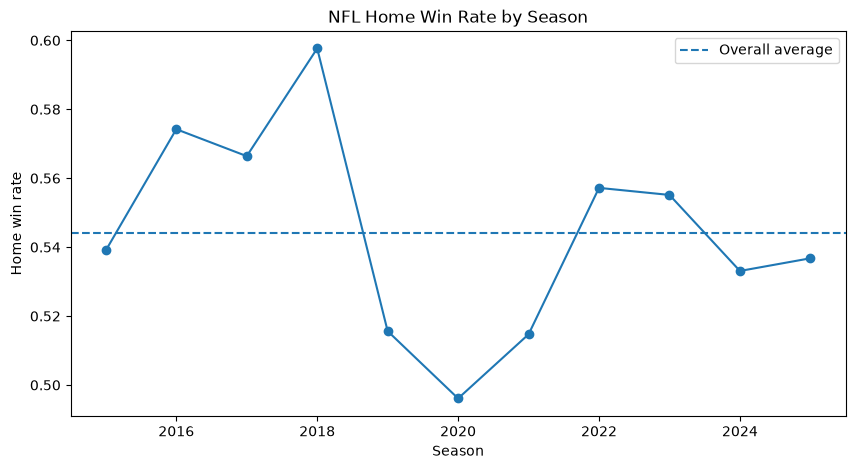

In [31]:
plt.figure(figsize=(10, 5))

plt.plot(
    home_win_by_year["season"],
    home_win_by_year["home_win_rate"],
    marker="o"
)

plt.axhline(
    games["home_win"].mean(),
    linestyle="--",
    label="Overall average"
)

plt.xlabel("Season")
plt.ylabel("Home win rate")
plt.title("NFL Home Win Rate by Season")
plt.legend()
plt.show()

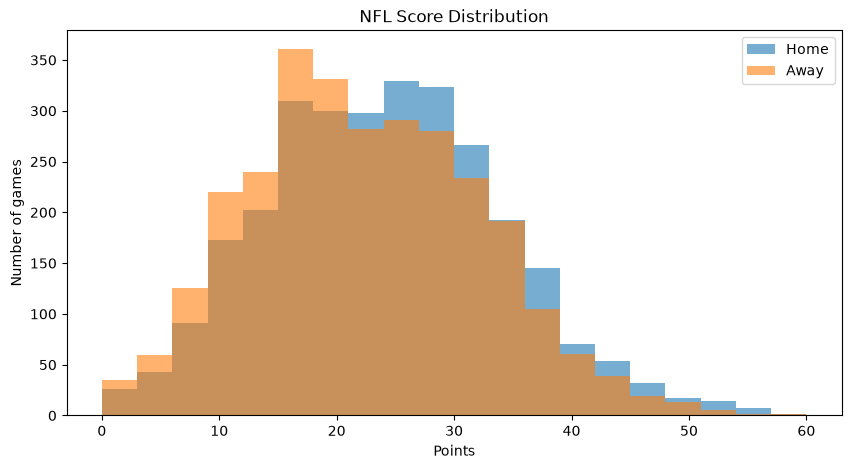

In [32]:
plt.figure(figsize=(10, 5))

plt.hist(
    games["home_score"],
    bins=range(0, 61, 3),
    alpha=0.6,
    label="Home"
)

plt.hist(
    games["away_score"],
    bins=range(0, 61, 3),
    alpha=0.6,
    label="Away"
)

plt.xlabel("Points")
plt.ylabel("Number of games")
plt.title("NFL Score Distribution")
plt.legend()
plt.show()

In [33]:
games = games.with_columns(
    pl.col("score_diff")
    .abs()
    .alias("margin")
)

In [34]:
games.select([
    pl.col("margin").mean().alias("mean_margin"),
    pl.col("margin").median().alias("median_margin"),
])

mean_margin,median_margin
f64,f64
11.127461,8.0


In [35]:
games = games.with_columns(
    pl.when(pl.col("margin") <= 3)
      .then(pl.lit("1-3"))
      .when(pl.col("margin") <= 7)
      .then(pl.lit("4-7"))
      .when(pl.col("margin") <= 14)
      .then(pl.lit("8-14"))
      .otherwise(pl.lit("15+"))
      .alias("margin_category")
)

In [36]:
games.group_by("margin_category").agg(
    pl.len().alias("games")
).sort("margin_category")

margin_category,games
str,u32
"""1-3""",700
"""15+""",844
"""4-7""",715
"""8-14""",636


In [37]:
home_counts = (
    games
    .group_by("home_team")
    .agg(pl.len().alias("home_games"))
)

away_counts = (
    games
    .group_by("away_team")
    .agg(pl.len().alias("away_games"))
)

team_counts = (
    home_counts
    .join(
        away_counts,
        left_on="home_team",
        right_on="away_team",
        how="full"
    )
)

team_counts

home_team,home_games,away_team,away_games
str,u32,str,u32
"""CLE""",91,"""CLE""",90
"""DET""",90,"""DET""",91
"""TEN""",91,"""TEN""",90
"""PHI""",90,"""PHI""",91
"""MIN""",90,"""MIN""",91
…,…,…,…
"""ATL""",90,"""ATL""",91
"""DAL""",90,"""DAL""",91
"""GB""",90,"""GB""",91


In [38]:
games.select([
    pl.col("home_score").null_count().alias("missing_home_score"),
    pl.col("away_score").null_count().alias("missing_away_score"),
])

missing_home_score,missing_away_score
u32,u32
0,0


In [40]:
games.select([
    pl.col("overtime").value_counts()
])

overtime
struct[2]
"{1,165}"
"{0,2730}"


DATASET
2015–2025 regular-season games
N games
N seasons
N teams

TARGET
Home win rate = X%

SCORING
Average home score = X
Average away score = X
Average margin = X

HOME ADVANTAGE
Home win rate by season
Trend over time

GAME OUTCOMES
Close games
Blowouts
Overtime

DATA QUALITY
Missing values
Duplicates
Team naming/relocation issues

NEXT STEP
Build pre-game team strength features